In [21]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [22]:
root_output_directory = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/hainich"
scenario_name = "broad_local_anet_fix"
input_path = os.path.join(root_output_directory,scenario_name,'input')
output_path = os.path.join(root_output_directory,scenario_name,'output')
post_path = os.path.join(root_output_directory,scenario_name,'post')
if not os.path.exists(post_path):
    os.makedirs(post_path)

In [23]:
df_rmse = xr.open_dataset(os.path.join(output_path,'Sens_Output0.nc')).to_dataframe()
df_rmse

,RMSE_J,RMSE_G,RMSE_psi_stem
run_id,,,
0,0.000287,0.000291,0.190934
1,0.000337,0.000384,0.156402
2,0.000391,0.000452,0.257209
3,0.000360,0.000374,0.117304
4,0.000328,0.000396,0.078511
...,...,...,...
99995,0.000348,0.000452,0.112147
99996,0.000303,0.000461,0.251033
99997,0.000377,0.000435,0.144992


In [24]:
df_s = pd.read_csv(os.path.join(input_path,'Hainich_parameters.csv'))
df_s

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,organic_matter_fracs,theta_r,theta_s,camp_b,pore_size_ind,tree_density,sigma_log_likelyhood,soil_profile_index,theta_emp_multiplier,solver_precision
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,2.297715,972.935,...,0.05;0.05;0.05,0.06172335;0.06172335;0.06172335,0.49042445;0.49042445;0.49042445,8.4;8.4;8.4,0.56999821;0.56999821;0.56999821,0.006456,1.0,2,1.0,1.000000e-10
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.434424,972.935,...,0.05;0.05;0.05,0.05135015;0.05135015;0.05135015,0.49288981;0.49288981;0.49288981,8.4;8.4;8.4,0.54859503;0.54859503;0.54859503,0.006153,1.0,2,1.0,1.000000e-10
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.377205,972.935,...,0.05;0.05;0.05,0.0851526;0.0851526;0.0851526,0.47277855;0.47277855;0.47277855,8.4;8.4;8.4,0.58726021;0.58726021;0.58726021,0.007138,1.0,2,1.0,1.000000e-10
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,2.082578,972.935,...,0.05;0.05;0.05,0.07889182;0.07889182;0.07889182,0.49335003;0.49335003;0.49335003,8.4;8.4;8.4,0.56579627;0.56579627;0.56579627,0.005574,1.0,2,1.0,1.000000e-10
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,2.246155,972.935,...,0.05;0.05;0.05,0.06503056;0.06503056;0.06503056,0.48485999;0.48485999;0.48485999,8.4;8.4;8.4,0.59383667;0.59383667;0.59383667,0.007272,1.0,2,1.0,1.000000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.368329,972.935,...,0.05;0.05;0.05,0.07907674;0.07907674;0.07907674,0.48320364;0.48320364;0.48320364,8.4;8.4;8.4,0.54614774;0.54614774;0.54614774,0.006873,1.0,2,1.0,1.000000e-10
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,2.297984,972.935,...,0.05;0.05;0.05,0.08751771;0.08751771;0.08751771,0.49635934;0.49635934;0.49635934,8.4;8.4;8.4,0.57932782;0.57932782;0.57932782,0.006093,1.0,2,1.0,1.000000e-10
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,2.857258,972.935,...,0.05;0.05;0.05,0.08053592;0.08053592;0.08053592,0.46230957;0.46230957;0.46230957,8.4;8.4;8.4,0.57991684;0.57991684;0.57991684,0.007117,1.0,2,1.0,1.000000e-10
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,2.225331,972.935,...,0.05;0.05;0.05,0.07398077;0.07398077;0.07398077,0.48176299;0.48176299;0.48176299,8.4;8.4;8.4,0.59837688;0.59837688;0.59837688,0.006312,1.0,2,1.0,1.000000e-10


In [25]:
if df_s.shape[0] != df_s.shape[0]:
    print("Error dataframes do not match in size")

In [26]:
df_s['psi_soil_sat0'] = df_s['psi_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['k_soil_sat0'] = df_s['k_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_s0'] = df_s['theta_s'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_r0'] = df_s['theta_r'].str.split(';', expand=True).values[:,0].astype(float)
df_s['pore_0'] = df_s['pore_size_ind'].str.split(';', expand=True).values[:,0].astype(float)

In [27]:
df_d = pd.concat([df_s, df_rmse], axis=1)

In [28]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,theta_emp_multiplier,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,2.297715,972.935,...,1.0,1.000000e-10,-0.088395,3.230872e-07,0.490424,0.061723,0.569998,0.000287,0.000291,0.190934
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.434424,972.935,...,1.0,1.000000e-10,-0.001967,1.369353e-07,0.492890,0.051350,0.548595,0.000337,0.000384,0.156402
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.377205,972.935,...,1.0,1.000000e-10,-0.024434,2.001595e-07,0.472779,0.085153,0.587260,0.000391,0.000452,0.257209
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,2.082578,972.935,...,1.0,1.000000e-10,-0.067681,6.440061e-07,0.493350,0.078892,0.565796,0.000360,0.000374,0.117304
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,2.246155,972.935,...,1.0,1.000000e-10,-0.001724,1.718914e-07,0.484860,0.065031,0.593837,0.000328,0.000396,0.078511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.368329,972.935,...,1.0,1.000000e-10,-0.029611,8.884224e-07,0.483204,0.079077,0.546148,0.000348,0.000452,0.112147
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,2.297984,972.935,...,1.0,1.000000e-10,-0.021031,2.865913e-07,0.496359,0.087518,0.579328,0.000303,0.000461,0.251033
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,2.857258,972.935,...,1.0,1.000000e-10,-0.060561,3.153229e-07,0.462310,0.080536,0.579917,0.000377,0.000435,0.144992
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,2.225331,972.935,...,1.0,1.000000e-10,-0.033013,5.182526e-07,0.481763,0.073981,0.598377,0.000280,0.000360,0.212729


In [29]:
max_rmse_J = 0.000347
max_rmse_psi_stem = 0.0668
df_d['RMSE_com_avg'] = (df_d['RMSE_psi_stem'] / max_rmse_psi_stem + df_d['RMSE_J'] / max_rmse_J) / 2.0;

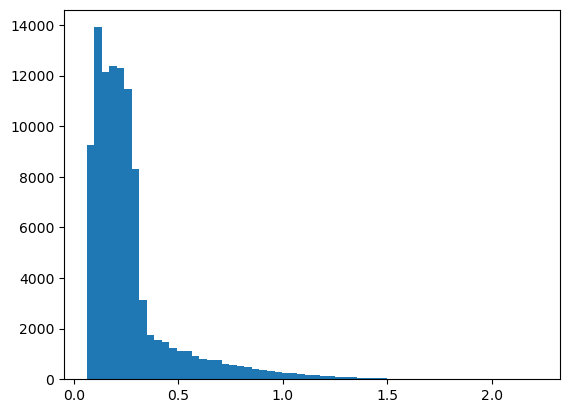

In [30]:
plt.hist(df_d['RMSE_psi_stem'], bins =60);

In [33]:
df_psi_stem = df_d.loc[df_d['RMSE_psi_stem'] < 0.07]
print(df_psi_stem.shape)

(903, 52)


In [36]:
df_J= df_d.loc[df_d['RMSE_J'] < 0.00025]
print(df_J.shape)

(1027, 52)


Text(0.5, 1.0, 'pore_0')

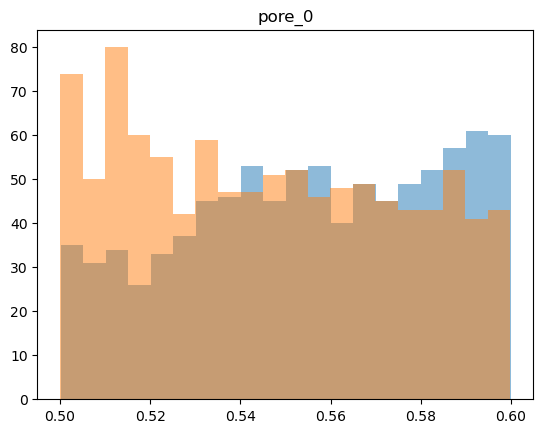

In [37]:
plt.hist(df_psi_stem['pore_0'], alpha = 0.5, bins = 20);
plt.hist(df_J['pore_0'], alpha = 0.5, bins = 20);
plt.title("pore_0")

In [38]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem','leaf_area_index', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'theta_s0', 'pore_0', 'theta_r0', 'anet_max', 'root_area_index', 'tree_density' ]

for var in vars:
    
    if var == 'leaf_hydraulic_capacitance':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    elif var == 'k_soil_sat0':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    else:
        plt.hist(df_psi_stem[var], alpha = 0.5, bins = 20);
        plt.hist(df_J[var], alpha = 0.5, bins = 20);

    plt.title(var)
    plt.savefig(f"{post_path}/hist_{var}.png")
    plt.close()

In [39]:
df_psi_stem

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
49,49,49,1800.0,1800,False,1.0,4.0,Weibull,2.718740,972.935,...,1.000000e-10,-0.094435,3.207478e-07,0.496395,0.074123,0.576184,0.000389,0.000479,0.067568,1.066442
109,109,109,1800.0,1800,False,1.0,4.0,Weibull,2.065686,972.935,...,1.000000e-10,-0.010390,1.695906e-07,0.460009,0.084277,0.573596,0.000434,0.000518,0.069916,1.148801
133,133,133,1800.0,1800,False,1.0,4.0,Weibull,2.919328,972.935,...,1.000000e-10,-0.050796,1.383033e-07,0.465493,0.054061,0.575527,0.000476,0.000466,0.064740,1.169744
370,370,370,1800.0,1800,False,1.0,4.0,Weibull,2.016276,972.935,...,1.000000e-10,-0.089729,1.763121e-07,0.486075,0.073856,0.597689,0.000282,0.000318,0.064850,0.891598
450,450,450,1800.0,1800,False,1.0,4.0,Weibull,2.117478,972.935,...,1.000000e-10,-0.025919,1.889759e-07,0.471750,0.061545,0.590297,0.000300,0.000401,0.068221,0.943243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99124,99124,99124,1800.0,1800,False,1.0,4.0,Weibull,2.966496,972.935,...,1.000000e-10,-0.033174,3.763607e-07,0.492146,0.063066,0.557483,0.000390,0.000422,0.069701,1.083826
99491,99491,99491,1800.0,1800,False,1.0,4.0,Weibull,2.522362,972.935,...,1.000000e-10,-0.005109,6.339620e-07,0.491790,0.085314,0.576970,0.000328,0.000388,0.065681,0.964141
99690,99690,99690,1800.0,1800,False,1.0,4.0,Weibull,2.055358,972.935,...,1.000000e-10,-0.051580,3.644438e-07,0.484574,0.086855,0.567108,0.000371,0.000407,0.067361,1.038601
99888,99888,99888,1800.0,1800,False,1.0,4.0,Weibull,2.662113,972.935,...,1.000000e-10,-0.053802,7.598449e-07,0.495614,0.073404,0.516186,0.000287,0.000327,0.065657,0.905524


In [40]:
best_common = np.intersect1d(df_psi_stem.index, df_J.index)

In [41]:
df_best_c  = df_d.iloc[best_common]
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
6029,6029,6029,1800.0,1800,False,1.0,4.0,Weibull,2.361092,972.935,...,1.000000e-10,-0.074279,1.843652e-07,0.481796,0.065712,0.582022,0.000238,0.000313,0.069374,0.862908
48153,48153,48153,1800.0,1800,False,1.0,4.0,Weibull,2.155829,972.935,...,1.000000e-10,-0.015859,2.144648e-07,0.469309,0.067641,0.543555,0.000249,0.000322,0.069231,0.877340
54691,54691,54691,1800.0,1800,False,1.0,4.0,Weibull,2.629129,972.935,...,1.000000e-10,-0.037072,2.068330e-07,0.488143,0.074033,0.569874,0.000250,0.000303,0.067088,0.862233
59655,59655,59655,1800.0,1800,False,1.0,4.0,Weibull,2.408138,972.935,...,1.000000e-10,-0.056213,2.493712e-07,0.460418,0.054506,0.512624,0.000247,0.000322,0.068539,0.868614
63870,63870,63870,1800.0,1800,False,1.0,4.0,Weibull,2.343961,972.935,...,1.000000e-10,-0.042018,2.854762e-07,0.470505,0.065712,0.541231,0.000239,0.000307,0.068662,0.858843
83165,83165,83165,1800.0,1800,False,1.0,4.0,Weibull,2.783040,972.935,...,1.000000e-10,-0.028286,3.267113e-07,0.492570,0.059184,0.558836,0.000228,0.000295,0.067411,0.832389
88036,88036,88036,1800.0,1800,False,1.0,4.0,Weibull,2.231688,972.935,...,1.000000e-10,-0.093177,1.615093e-07,0.496231,0.066149,0.568485,0.000240,0.000324,0.069832,0.867978
91137,91137,91137,1800.0,1800,False,1.0,4.0,Weibull,2.244880,972.935,...,1.000000e-10,-0.011991,2.269741e-07,0.473052,0.075370,0.554906,0.000237,0.000295,0.066685,0.840700
92704,92704,92704,1800.0,1800,False,1.0,4.0,Weibull,2.491757,972.935,...,1.000000e-10,-0.016545,2.361168e-07,0.494302,0.055957,0.556887,0.000245,0.000313,0.066493,0.851241


In [42]:
m = 0.9570685625076294

In [43]:
df_best_psi_stem = df_d.sort_values(by='RMSE_psi_stem').iloc[0:10]
df_best_psi_stem.to_csv(f"{input_path}/parameters_best_psi_stem.csv")
df_best_J = df_d.sort_values(by='RMSE_J').iloc[0:10]
df_best_J.to_csv(f"{input_path}/parameters_best_J.csv")
df_best_both = df_d.sort_values(by='RMSE_com_avg').iloc[0:10]
df_best_both.to_csv(f"{input_path}/parameters_best_both.csv")


In [46]:
df_best_c['RMSE_com_avg']

6029     0.862908
48153    0.877340
54691    0.862233
59655    0.868614
63870    0.858843
83165    0.832389
88036    0.867978
91137    0.840700
92704    0.851241
Name: RMSE_com_avg, dtype: float32

In [48]:
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
6029,6029,6029,1800.0,1800,False,1.0,4.0,Weibull,2.361092,972.935,...,1.000000e-10,-0.074279,1.843652e-07,0.481796,0.065712,0.582022,0.000238,0.000313,0.069374,0.862908
48153,48153,48153,1800.0,1800,False,1.0,4.0,Weibull,2.155829,972.935,...,1.000000e-10,-0.015859,2.144648e-07,0.469309,0.067641,0.543555,0.000249,0.000322,0.069231,0.877340
54691,54691,54691,1800.0,1800,False,1.0,4.0,Weibull,2.629129,972.935,...,1.000000e-10,-0.037072,2.068330e-07,0.488143,0.074033,0.569874,0.000250,0.000303,0.067088,0.862233
59655,59655,59655,1800.0,1800,False,1.0,4.0,Weibull,2.408138,972.935,...,1.000000e-10,-0.056213,2.493712e-07,0.460418,0.054506,0.512624,0.000247,0.000322,0.068539,0.868614
63870,63870,63870,1800.0,1800,False,1.0,4.0,Weibull,2.343961,972.935,...,1.000000e-10,-0.042018,2.854762e-07,0.470505,0.065712,0.541231,0.000239,0.000307,0.068662,0.858843
83165,83165,83165,1800.0,1800,False,1.0,4.0,Weibull,2.783040,972.935,...,1.000000e-10,-0.028286,3.267113e-07,0.492570,0.059184,0.558836,0.000228,0.000295,0.067411,0.832389
88036,88036,88036,1800.0,1800,False,1.0,4.0,Weibull,2.231688,972.935,...,1.000000e-10,-0.093177,1.615093e-07,0.496231,0.066149,0.568485,0.000240,0.000324,0.069832,0.867978
91137,91137,91137,1800.0,1800,False,1.0,4.0,Weibull,2.244880,972.935,...,1.000000e-10,-0.011991,2.269741e-07,0.473052,0.075370,0.554906,0.000237,0.000295,0.066685,0.840700
92704,92704,92704,1800.0,1800,False,1.0,4.0,Weibull,2.491757,972.935,...,1.000000e-10,-0.016545,2.361168e-07,0.494302,0.055957,0.556887,0.000245,0.000313,0.066493,0.851241


In [49]:
df_d.iloc[83165]

Unnamed: 0                                                       83165
id                                                               83165
dts                                                             1800.0
dts_input                                                         1800
verbose                                                          False
max_psi_leaf_change_per_hour                                       1.0
minimum_psi_leaf_multiplier                                        4.0
conductivity_fraction_type                                     Weibull
anet_max                                                       2.78304
sw_rad_max                                                     972.935
sustain_xylem_damage                                             False
root_area_index                                               2.150282
canopy_height                                                       31
stem_flow_type                                                  Linear
eta_LS